Top Churn Drivers (Positive) and Retention Drivers (Negative):
                                           Feature  Coefficient
10            encoder__InternetService_Fiber optic     1.222352
2                                num__TotalCharges     0.486541
23                    encoder__StreamingMovies_Yes     0.420611
28         encoder__PaymentMethod_Electronic check     0.402478
21                        encoder__StreamingTV_Yes     0.395359
26                   encoder__PaperlessBilling_Yes     0.336449
9                       encoder__MultipleLines_Yes     0.324742
5                         encoder__SeniorCitizen_1     0.153869
29             encoder__PaymentMethod_Mailed check     0.052313
17                   encoder__DeviceProtection_Yes     0.041152
3                             encoder__gender_Male     0.030555
6                             encoder__Partner_Yes     0.018776
27  encoder__PaymentMethod_Credit card (automatic)    -0.000671
15                       encoder__OnlineB

C:\Users\Eleftheria\AppData\Local\Temp\ipykernel_11936\2749836843.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=top_features, palette='coolwarm')


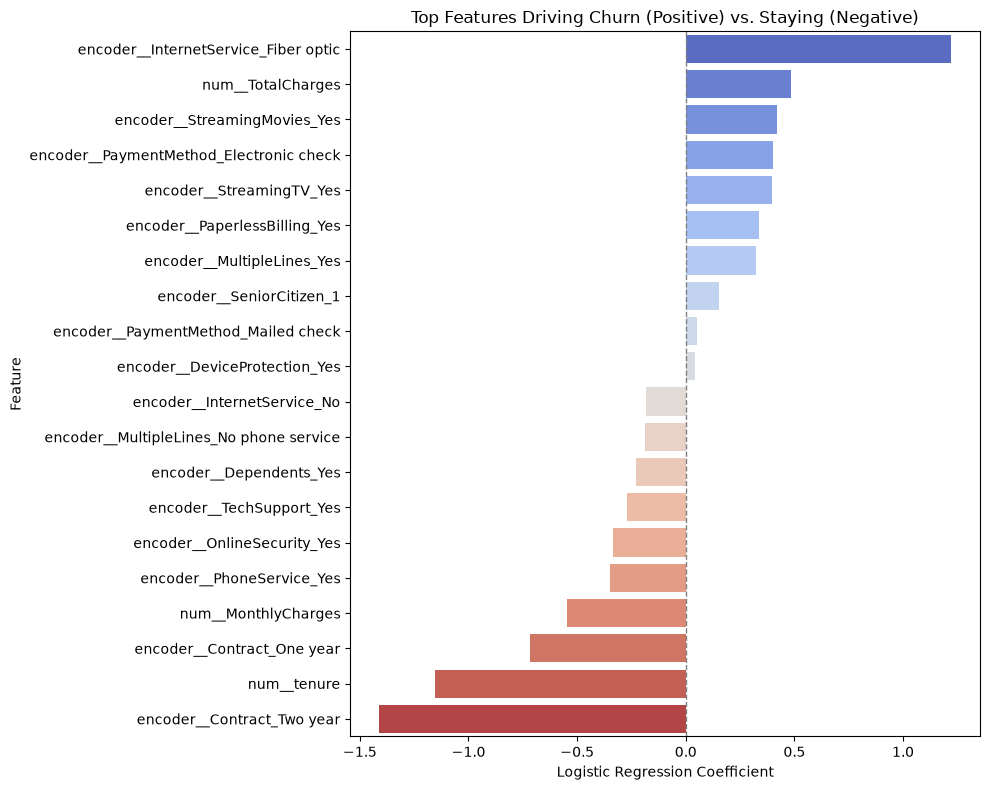


Accuracy LR: 0.74
Accuracy RF: 0.77

Confusion Matrix LR:
[[747 288]
 [ 81 293]]

Confusion Matrix RF:
[[849 186]
 [139 235]]

Classification Report LR:
              precision    recall  f1-score   support

          No       0.90      0.72      0.80      1035
         Yes       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Classification Report RF:
              precision    recall  f1-score   support

          No       0.86      0.82      0.84      1035
         Yes       0.56      0.63      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.77      0.77      1409



In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ==========================================
# 1. LOAD AND PREPARE DATA
# ==========================================
# Load the raw dataset
df = pd.read_csv("../data/customer_data.csv")

# Drop unique identifier columns that add no predictive value
clean_data = df.drop(["customerID"], axis=1)

# Split features (X) and target (y)
X = clean_data.drop(columns=['Churn'])
y = clean_data['Churn']

# Stratified train-test split to maintain class balance proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# 2. BUILD PREPROCESSING PIPELINE
# ==========================================
# ColumnTransformer handles numerical and categorical transformations separately
transformer = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')), # Handle missing numerical values
        ('scaler', StandardScaler())                 # Normalize numerical features
    ]), ['tenure', 'MonthlyCharges', 'TotalCharges']),
    
    ('encoder', OneHotEncoder(sparse_output=False, drop='first'), [
        'gender', 'Dependents', 'SeniorCitizen', 'Partner', 'PhoneService', 
        'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
        'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
        'Contract', 'PaperlessBilling', 'PaymentMethod'
    ])
], remainder='passthrough')

# ==========================================
# 3. MODEL 1: LOGISTIC REGRESSION
# ==========================================
# Combine preprocessor and model into a single Pipeline
pipelineLR = Pipeline([
    ('transformer', transformer),
    ('classifier', LogisticRegression(class_weight='balanced'))
])

# Train the Logistic Regression model
pipelineLR.fit(X_train, y_train)
y_predLR = pipelineLR.predict(X_test)

#Serialization of the Logistic Regression model
filenameLR = '../models/pipelineLR.sav'
joblib.dump(pipelineLR, filenameLR)

# --- Feature Importance Extraction for Logistic Regression ---
# Extract feature names generated by the ColumnTransformer
feature_names = pipelineLR.named_steps['transformer'].get_feature_names_out()
# Extract learned weights (coefficients)
coefficients = pipelineLR.named_steps['classifier'].coef_[0]

# Create a summary DataFrame of feature drivers
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print("Top Churn Drivers (Positive) and Retention Drivers (Negative):")
print(importance_df.head(15))

# Visualize top positive and negative feature coefficients
plt.figure(figsize=(10, 8))
top_features = pd.concat([importance_df.head(10), importance_df.tail(10)])
sns.barplot(x='Coefficient', y='Feature', data=top_features, palette='coolwarm')
plt.title('Top Features Driving Churn (Positive) vs. Staying (Negative)')
plt.xlabel('Logistic Regression Coefficient')
plt.ylabel('Feature')
plt.axvline(x=0, color='grey', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


# ==========================================
# 4. MODEL 2: RANDOM FOREST CLASSIFIER
# ==========================================
pipelineRF = Pipeline([
    ('transformer', transformer),
    ('classifier', RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42))
])

# Train the Random Forest model
pipelineRF.fit(X_train, y_train)
y_predRF = pipelineRF.predict(X_test)

#Serialization of the Random Forest model
filenameRF = '../models/pipelineRF.sav'
joblib.dump(pipelineRF, filenameRF)

# ==========================================
# 5. MODEL EVALUATION & COMPARISON
# ==========================================
print(f"\nAccuracy LR: {accuracy_score(y_test, y_predLR):.2f}")
print(f"Accuracy RF: {accuracy_score(y_test, y_predRF):.2f}\n")

print("Confusion Matrix LR:")
print(confusion_matrix(y_test, y_predLR))
print("\nConfusion Matrix RF:")
print(confusion_matrix(y_test, y_predRF))

print("\nClassification Report LR:")
print(classification_report(y_test, y_predLR))
print("Classification Report RF:")
print(classification_report(y_test, y_predRF))